# Task 3: Customer Churn Prediction
**CodSoft ML Internship**

Goal: Predict if a bank customer will churn (leave) using historical data.

## Step 1: Install & Import Libraries

In [3]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 8.5 MB/s eta 0:00:12
   - -------------------------------------- 2.6/101.7 MB 10.8 MB/s eta 0:00:10
   -- ------------------------------------- 5.2/101.7 MB 11.0 MB/s eta 0:00:09
   -- ------------------------------------- 7.1/101.7 MB 10.6 MB/s eta 0:00:09
   --- ------------------------------------ 9.4/101.7 MB 10.5 MB/s eta 0:00:09
   ---- ----------------------------------- 12.1/101.7 MB 10.9 MB/s eta 0:00:09
   ----- ---------------------------------- 14.4/101.7 MB 10.9 MB/s eta 0:00:08
   ------ --------------------------------- 16.8/101.7 MB 11.0 MB/s eta 0:00:08
   ------- -------------------------------- 19.4/101.7 MB 11.2 MB/s eta 0:00:08
   -------- ------------------------------- 21.8/101.7 MB 11.3 MB/s eta 0:00:08
   --------- ------------------------------ 24.4/101.7 MB 11.3 MB/s eta 0:00:07
   ---------- ----------------------------- 27.0/101.7 


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

**How to download the dataset:**
1. Go to: https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction
2. Click **Download**
3. Extract the zip — you'll get `Churn_Modelling.csv`
4. Place the CSV file in the **same folder as this notebook**

In [6]:
df = pd.read_csv('Churn_Modelling.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 3: Explore the Data

In [8]:
print('Columns:', df.columns.tolist())
print('\nData info:')
df.info()
print('\nMissing values:')
print(df.isnull().sum())

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64

Churn distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.37%


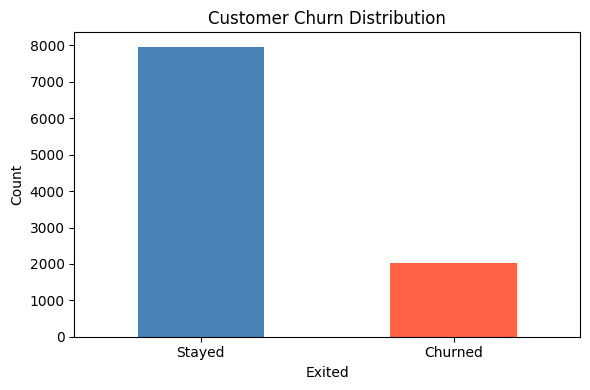

In [9]:
# Check churn distribution
churn_counts = df['Exited'].value_counts()
print('Churn distribution:')
print(churn_counts)
print(f'\nChurn rate: {churn_counts[1]/len(df)*100:.2f}%')

plt.figure(figsize=(6, 4))
churn_counts.plot(kind='bar', color=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Stayed', 'Churned'], rotation=0)
plt.title('Customer Churn Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

In [10]:
# Statistical summary
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


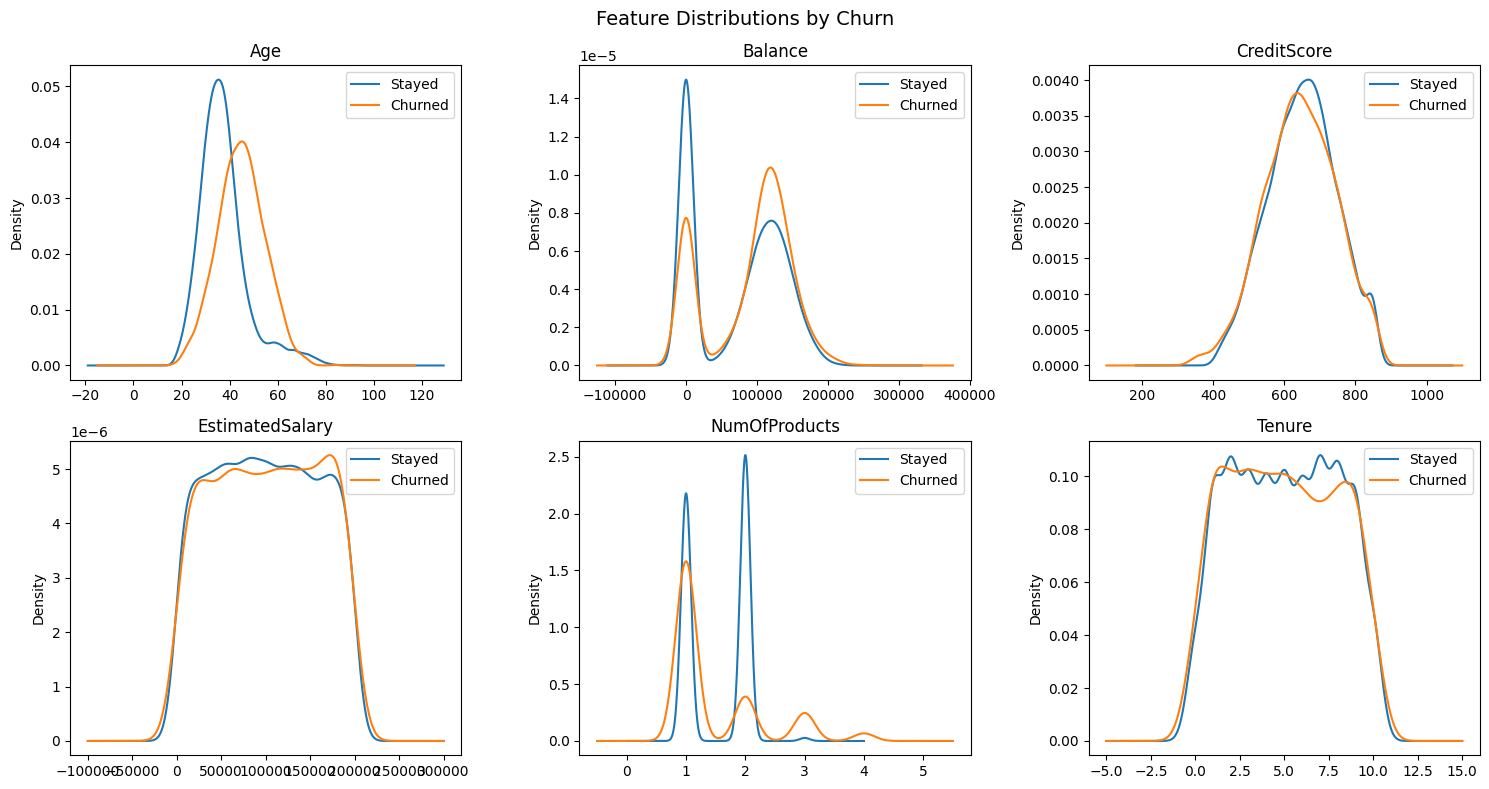

In [11]:
# Visualize key features vs Churn
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_features = ['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'NumOfProducts', 'Tenure']

for ax, feat in zip(axes.flat, num_features):
    df.groupby('Exited')[feat].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(feat)
    ax.legend(['Stayed', 'Churned'])

plt.suptitle('Feature Distributions by Churn', fontsize=14)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

## Step 4: Preprocess the Data

In [13]:
# Drop non-informative columns
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Encode categorical columns
le_geo    = LabelEncoder()
le_gender = LabelEncoder()
df['Geography'] = le_geo.fit_transform(df['Geography'])
df['Gender']    = le_gender.fit_transform(df['Gender'])

print('Preprocessed data:')
df.head()

Preprocessed data:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


## Step 5: Correlation Heatmap

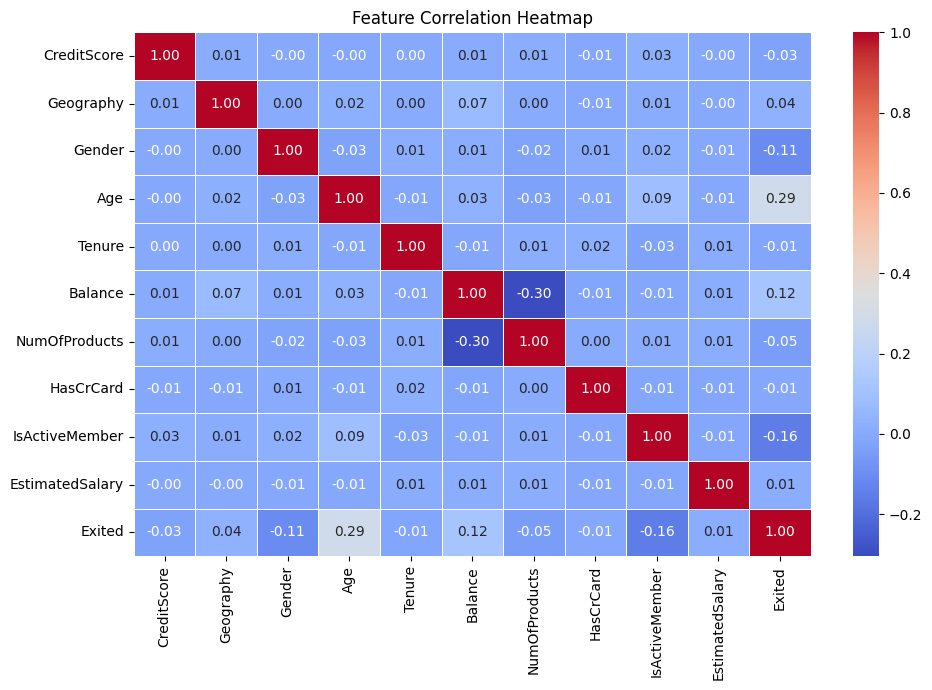

In [15]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

## Step 6: Train-Test Split & Scaling

In [17]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Train size:', X_train_scaled.shape)
print('Test size: ', X_test_scaled.shape)

Train size: (8000, 10)
Test size:  (2000, 10)


## Step 7: Train & Compare 3 Models

In [19]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc   = accuracy_score(y_test, preds)
    roc   = roc_auc_score(y_test, preds)
    results[name] = {'model': model, 'accuracy': acc, 'roc_auc': roc, 'preds': preds}
    print(f'{name}: Accuracy={acc:.4f} | ROC-AUC={roc:.4f}')

Logistic Regression: Accuracy=0.8050 | ROC-AUC=0.5584
Random Forest: Accuracy=0.8595 | ROC-AUC=0.7069
Gradient Boosting: Accuracy=0.8700 | ROC-AUC=0.7291


In [20]:
# Best model report
best_name = max(results, key=lambda x: results[x]['roc_auc'])
print(f'Best Model: {best_name}\n')
print(classification_report(y_test, results[best_name]['preds'], target_names=['Stayed', 'Churned']))

Best Model: Gradient Boosting

              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
     Churned       0.79      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



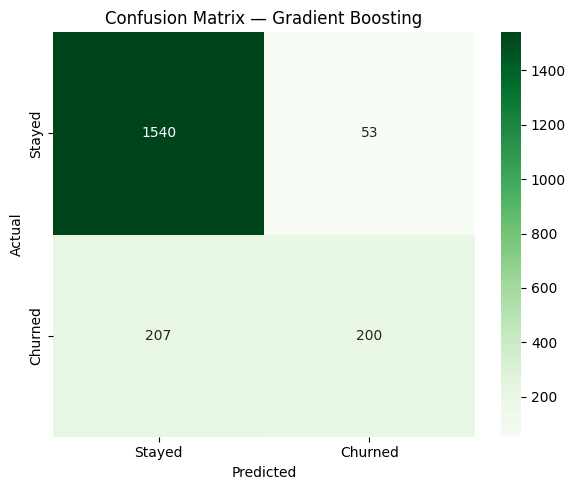

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, results[best_name]['preds'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('churn_confusion_matrix.png', dpi=150)
plt.show()

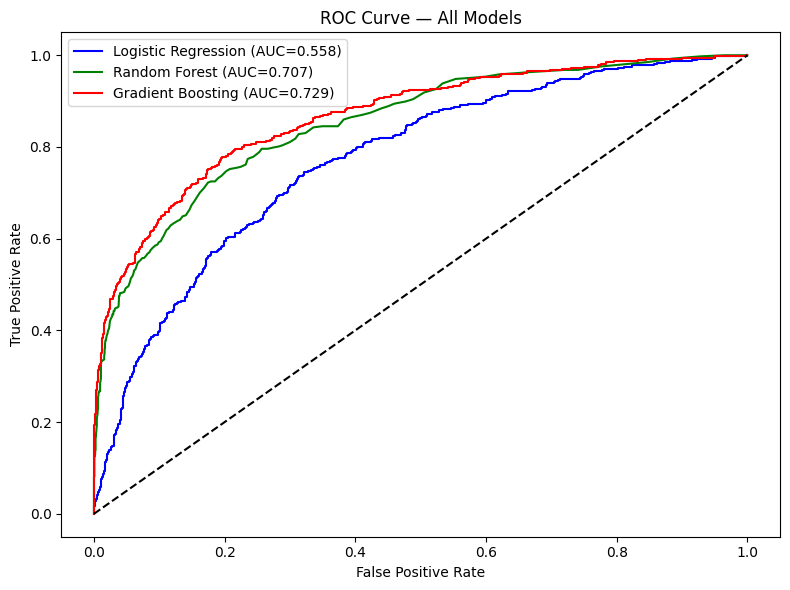

In [22]:
# ROC Curve comparison for all 3 models
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
for (name, res), color in zip(results.items(), colors):
    proba = res['model'].predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, color=color, label=f"{name} (AUC={res['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend()
plt.tight_layout()
plt.savefig('churn_roc_curves.png', dpi=150)
plt.show()

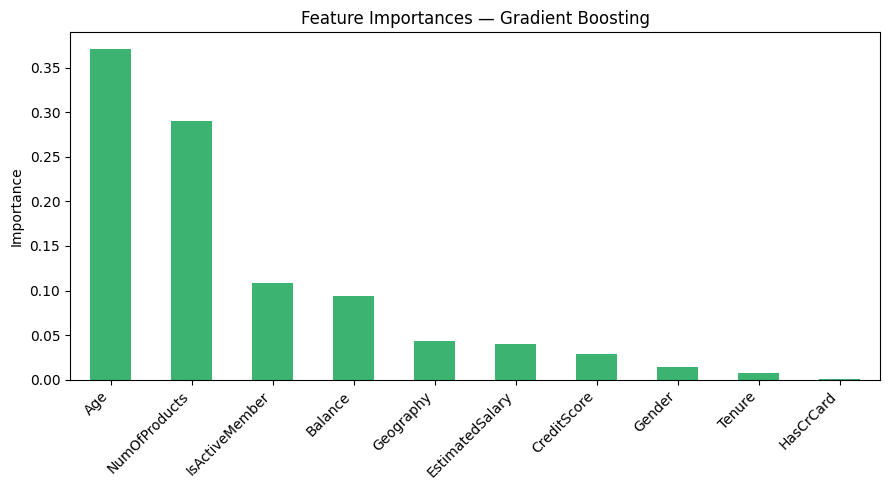

In [23]:
# Feature Importance
best_model = results[best_name]['model']
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(9, 5))
    importances.plot(kind='bar', color='mediumseagreen')
    plt.title(f'Feature Importances — {best_name}')
    plt.ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('churn_feature_importance.png', dpi=150)
    plt.show()

## Step 8: Predict on a New Customer

In [25]:
def predict_churn(customer_data: dict):
    """
    customer_data: dict with keys matching df columns (after encoding)
    Example: {'CreditScore':600, 'Geography':0, 'Gender':1, 'Age':40,
              'Tenure':3, 'Balance':60000, 'NumOfProducts':2,
              'HasCrCard':1, 'IsActiveMember':1, 'EstimatedSalary':50000}
    """
    input_df = pd.DataFrame([customer_data])
    scaled   = scaler.transform(input_df)
    pred     = best_model.predict(scaled)[0]
    prob     = best_model.predict_proba(scaled)[0][1]
    label    = 'Churned' if pred == 1 else 'Stayed'
    print(f'Prediction: {label} (Churn probability: {prob:.2%})')

# Example customer
sample_customer = {
    'CreditScore': 600, 'Geography': 0, 'Gender': 1,
    'Age': 45, 'Tenure': 2, 'Balance': 80000.0,
    'NumOfProducts': 1, 'HasCrCard': 1,
    'IsActiveMember': 0, 'EstimatedSalary': 100000.0
}

predict_churn(sample_customer)

Prediction: Stayed (Churn probability: 40.18%)


## ✅ Task 3 Complete!
- Loaded Bank Customer Churn dataset
- Explored data with visualizations
- Encoded categorical features
- Trained Logistic Regression, Random Forest, Gradient Boosting
- Evaluated with Accuracy, ROC-AUC, Confusion Matrix
- Built a prediction function for new customers